In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

**Creating dataframe for Yearly Returns of all companies**

In [18]:
all_yearly_returns = {}
stockdata_path = '/content/drive/MyDrive/IIMA_Internship/Energy_Sector/Data/Processed'

def load_stock_files(folder_path):
  files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]

  combined_returns = []

  for file in files:
    file_path = os.path.join(folder_path, file)

    stock_data = pd.read_csv(file_path)
    company_name = os.path.splitext(file)[0]

    stock_data.rename(columns = {'Change in price': 'Return', 'Percent change in price': '% Return'})

    stock_data['Date'] = pd.to_datetime(stock_data['Date'], errors = 'coerce')
    stock_data.dropna(subset=['Date'], inplace=True)
    stock_data['Year'] = stock_data['Date'].dt.year

    stock_data = stock_data.sort_values('Date')

    Yearly_agg = stock_data.groupby('Year').agg(
        Start_price = ('Adj Close', lambda x: x.iloc[0]),
        End_price = ('Adj Close', lambda x: x.iloc[-1])
    ).reset_index()

    # Yearly Return
    Yearly_agg['Yearly Return'] = (Yearly_agg['End_price'] - Yearly_agg['Start_price']) / Yearly_agg['Start_price'] * 100
    Yearly_agg['Company'] = company_name

    cols = Yearly_agg.columns.tolist()
    cols.insert(1, cols.pop(cols.index('Company')))
    Yearly_agg = Yearly_agg[cols]

    combined_returns.append(Yearly_agg)

    all_yearly_returns[company_name] = Yearly_agg


  # Combine all into one DataFrame
  all_returns_df = pd.concat(combined_returns, ignore_index=True)
  return all_returns_df

In [19]:
# Run the function and get the combined DataFrame
final_returns_df = load_stock_files(stockdata_path)
# final_returns_df[final_returns_df['Company'] == 'CASTROL']
final_returns_df['Company'].unique()

array(['POWERGRID', 'COALINDIA', 'IOC', 'ADANIGREEN', 'BPCL', 'RELIANCE',
       'TATAPOWER', 'NTPC', 'ADANIPOWER', 'ONGC', 'AEGISLOG', 'IGL',
       'GAIL', 'GUJGASLTD', 'MGL', 'HINDPETRO', 'CASTROLIND', 'GSPL',
       'PETRONET', 'ATGL', 'OIL', 'CHENNPETRO', 'GMDCLTD', 'SUZLON',
       'MRPL', 'INOXWIND'], dtype=object)

In [20]:
final_returns_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 507 entries, 0 to 506
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Year           507 non-null    int32  
 1   Company        507 non-null    object 
 2   Start_price    507 non-null    float64
 3   End_price      507 non-null    float64
 4   Yearly Return  507 non-null    float64
dtypes: float64(3), int32(1), object(1)
memory usage: 18.0+ KB


**Creating dataframe for ESG data of all companies**

In [21]:
# Cleaning the data

US_dollar_rate = 85.33

def clean_value(value):
  if type(value) == str:
    value = value.strip().replace(',', '')

    if value.startswith('INR '):
      return float(value.replace('INR ', ''))
    elif value.startswith('$'):
      usd = float(value.replace('$', ''))
      return usd * US_dollar_rate
    elif value.endswith('%'):
      try:
        return float(value.replace('%', ''))/100
      except ValueError:
        return value
    elif value.endswith(' Yrs'):
      return float(value.replace(' Yrs', ''))

  elif type(value) == int:
    return float(value)

  return value

In [22]:
# Setting the data in proper format

def proper_format(df):
  df = df.copy()
  df.drop(df.columns[0], axis=1, inplace=True)
  df.drop(index=[0,1,2,3], axis = 0, inplace = True)

  df.columns = df.iloc[0].astype(str).str[:4]
  df.columns.name = None
  df.rename(columns = {'Peri':'Parameter name'}, inplace = True)

  df = df[1:].reset_index(drop=True)
  df.drop(index=range(0,6), axis = 0, inplace = True)
  df['Parameter name'] = df['Parameter name'].str.replace(r"\s*\(.*?\)", "", regex=True).str.strip()


  df.replace({'--': np.nan, True: 1, False: 0}, inplace=True)
  df = df.map(clean_value)
  df.dropna(axis=0, subset = df.columns[1:],how='all', inplace=True)

  df = df.reset_index(drop=True)
  df = df.rename(columns={'Parameter name': 'index'})
  df = df.set_index('index').T


  df.index = df.index.astype(str)
  df = df[df.index.str.match(r'^\d{4}$')]  # Keep only 4-digit years
  df.index = df.index.astype(int)
  df.index.name = None

  for col in ['ESG Score', 'Environment Pillar Score', 'Social Pillar Score', 'Governance Pillar Score']:
    if col in df.columns:
        df.drop(col, axis=1, inplace=True)


  return df

In [23]:
# Combining the yearly ESG data of all companies


all_esg_data = {}
combined_E_data = []
combined_S_data = []
combined_G_data = []
combined_ESG_data = []


esg_path = '/content/drive/MyDrive/IIMA_Internship/Energy_Sector/Data/ESG_data/Raw_data'


def load_esg_files(folder_path):



  files = [f for f in os.listdir(folder_path) if f.endswith('.xlsx')]

  for file in files:
    file_path = os.path.join(folder_path, file)
    company_name = os.path.splitext(file)[0]

    try:
      xls = pd.ExcelFile(file_path)

      dfs = {sheet: proper_format(xls.parse(sheet)) for sheet in ['Environment', 'Social', 'Governance']}
      df_E = dfs['Environment'] #.add_prefix('E_')
      df_S = dfs['Social'] #.add_prefix('S_')
      df_G = dfs['Governance'] #.add_prefix('G_')

      for df, combined_list in zip([df_E, df_S, df_G],
                                                 [combined_E_data, combined_S_data, combined_G_data]):
                df = df.reset_index().rename(columns={'index': 'Year'})
                df['Company'] = company_name
                cols = df.columns.tolist()
                cols.insert(1, cols.pop(cols.index('Company')))
                df = df[cols]
                combined_list.append(df)

      # Merge all ESG sheets for the company
      df_esg = pd.concat([df_E, df_S, df_G], axis=1, join='inner')
      df_esg = df_esg.reset_index().rename(columns={'index': 'Year'})
      df_esg.index.name = None

      df_esg['Company'] = company_name

      # Reorder: Year, Company, ...
      cols = df_esg.columns.tolist()
      cols.insert(1, cols.pop(cols.index('Company')))
      df_esg = df_esg[cols]


      all_esg_data[company_name] = df_esg
      combined_ESG_data.append(df_esg)

    except Exception as e:
      print(f"Error processing {company_name}: {e}")


        # Combine all into one DataFrame
   # Create final combined DataFrames
  all_esg_df = pd.concat(combined_ESG_data, ignore_index=True)
  combined_E_df = pd.concat(combined_E_data, ignore_index=True)
  combined_S_df = pd.concat(combined_S_data, ignore_index=True)
  combined_G_df = pd.concat(combined_G_data, ignore_index=True)

  return all_esg_df, combined_E_df, combined_S_df, combined_G_df

In [24]:
# Run the function and get the combined DataFrame
final_ESG_df, final_E_df, final_S_df, final_G_df = load_esg_files(esg_path)

/tmp/ipython-input-22-3431930897.py:17: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({'--': np.nan, True: 1, False: 0}, inplace=True)
/tmp/ipython-input-22-3431930897.py:17: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({'--': np.nan, True: 1, False: 0}, inplace=True)
/tmp/ipython-input-22-3431930897.py:17: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the fut

In [25]:
ESG_parameters_list  = pd.read_csv('/content/drive/MyDrive/IIMA_Internship/Energy_Sector/Data/ESG_data/ESG_parameters_Siddhesh.csv' )
ESG_parameters_list.head()

ESG_parameters_list = ESG_parameters_list['Parameters'].to_list()

**Merging the Yearly Return with the yearly ESG data**

In [35]:
X = pd.merge(
    final_ESG_df,
    final_returns_df[['Company', 'Year', 'Yearly Return']],  # keep only required columns
    on=['Company', 'Year'],
    how='left'  # use 'left' join to keep all ESG rows even if return is missing
)

cols = X.columns.tolist()

# Remove 'Year' and 'Yearly Return' from current positions
cols.remove('Year')
cols.remove('Yearly Return')

# Insert 'Year' and 'Yearly Return' right after 'Company'
company_index = cols.index('Company')
cols.insert(company_index + 1, 'Year')
cols.insert(company_index + 2, 'Yearly Return')

# Reorder the DataFrame
X = X[cols]

In [36]:
X

,Company,Year,Yearly Return,Resource Reduction Policy,Policy Water Efficiency,Policy Energy Efficiency,Policy Sustainable Packaging,Policy Environmental Supply Chain,Resource Reduction Targets,Targets Water Efficiency,...,CAGR 5 Years GHG Emissions Intensity Scope 2,CAGR 3 Years Total CO2 Equivalent Emissions to Millions Revenues USD,CAGR 3 Years Total CO2 Equivalent Emissions,CAGR 3 Years GHG Emissions Direct Scope 1,CAGR 3 Years GHG Emissions Indirect Scope 2,CAGR 3 Years GHG Emissions Indirect Scope 3,CAGR 5 Years Total CO2 Equivalent Emissions to Millions Revenues USD,CAGR 5 Years Total CO2 Equivalent Emissions,CAGR 5 Years GHG Emissions Direct Scope 1 Percentage,CAGR 5 Years GHG Emissions Indirect Scope 2
0,AEGISLOG,2024,17.269628,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AEGISLOG,2023,NaN,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,AEGISLOG,2022,NaN,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,GSPL,2024,14.299722,1.0,1.0,1.0,0.0,1.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,GSPL,2023,15.444568,1.0,1.0,1.0,0.0,1.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
208,HINDPETRO,2020,-14.164566,1.0,1.0,1.0,0.0,1.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
209,HINDPETRO,2019,9.211668,1.0,1.0,1.0,0.0,1.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
210,HINDPETRO,2018,-35.857624,1.0,1.0,1.0,0.0,1.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
211,HINDPETRO,2017,47.752051,1.0,1.0,1.0,0.0,1.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
X.head()

**Preprocessing data**

In [32]:
X = X.dropna(subset='Yearly Return').reset_index(drop=True)


y = pd.DataFrame(X['Yearly Return'])
X = X.drop(['Year', 'Yearly Return'], axis=1)



In [33]:
to_remove = (list(set(ESG_parameters_list) - set(X.columns)))

for i in to_remove:
  ESG_parameters_list.remove(i)

In [34]:
X = X[['Company'] + ESG_parameters_list]

In [ ]:
X

,Company,Energy Use Total,Electricity Purchased,Renewable Energy Use Ratio,Total Renewable Energy,Renewable Energy Use,Total Water Use / Million in Revenue $,Water Withdrawal Total,Fresh Water Withdrawal Total,Water Recycled,...,SDG 8 Decent Work and Economic Growth,SDG 9 Industry Innovation and Infrastructure,SDG 10 Reduced Inequality,SDG 11 Sustainable Cities and Communities,SDG 12 Responsible Consumption and Production,SDG 13 Climate Action,SDG 14 Life Below Water,SDG 15 Life on Land,SDG 16 Peace and Justice Strong Institutions,SDG 17 Partnerships to achieve the Goal
0,AEGISLOG,37028.02,37001.74,0.4138,15322.74,1.0,21.75,18386.0,17900.0,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,CASTROL,27698.0,15314.0,0.2334,6466.0,1.0,75.16,45846.0,45846.0,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,CASTROL,21026.0,1771.0,0.0074,155.4,1.0,73.07,42175.0,42175.0,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,CASTROL,26994.0,13588.0,NaN,148.0,1.0,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,GSPL,185794.0,31827.04,NaN,328637.9,1.0,16.27,34934.0,34934.0,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180,GUJGASLTD,527751.38,484650.67,0.0,9.95,1.0,32.57,72040.96,72040.96,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
181,ADANIGREEN,1244612.44,161684.1,NaN,NaN,1.0,471.99,447630.0,447630.0,NaN,...,1.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0
182,ADANIGREEN,146708.0,139149.0,NaN,NaN,1.0,409.6,277002.0,277002.0,NaN,...,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0
183,ADANIGREEN,75280.0,66790.0,NaN,NaN,1.0,1234.98,527514.14,527514.14,52982.0,...,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [ ]:
print(X.isnull().mean())

X = X.drop(X.columns[X.isnull().mean() > 0.5], axis = 1)
print(X.shape)

Company                                         0.000000
Energy Use Total                                0.216216
Electricity Purchased                           0.481081
Renewable Energy Use Ratio                      0.945946
Total Renewable Energy                          0.540541
                                                  ...   
SDG 13 Climate Action                           0.291892
SDG 14 Life Below Water                         0.291892
SDG 15 Life on Land                             0.291892
SDG 16 Peace and Justice Strong Institutions    0.291892
SDG 17 Partnerships to achieve the Goal         0.291892
Length: 132, dtype: float64
(185, 83)


In [ ]:

# !pip install ydata-profiling
# import ydata_profiling as pp

In [ ]:
# ESG_EnvReport = pp.ProfileReport(final_E_df, explorative=True)
# ESG_EnvReport.to_file('ESG_EnvReport.html')

In [ ]:
# List all columns where at least one value is of type string
string_columns = [col for col in X.columns if X[col].apply(lambda x: isinstance(x, str)).any() and col != 'Company']

print("Columns containing string values:")
print(string_columns)

Columns containing string values:
[]


In [ ]:
X = X.drop(string_columns, axis = 1)
X.shape

(185, 83)

In [ ]:
X.head()

,Company,Energy Use Total,Electricity Purchased,Renewable Energy Use,Total Water Use / Million in Revenue $,Water Withdrawal Total,Fresh Water Withdrawal Total,Total Energy Use To EVIC USD in million,Water Use To EVIC USD in million,Targets Emissions,...,SDG 8 Decent Work and Economic Growth,SDG 9 Industry Innovation and Infrastructure,SDG 10 Reduced Inequality,SDG 11 Sustainable Cities and Communities,SDG 12 Responsible Consumption and Production,SDG 13 Climate Action,SDG 14 Life Below Water,SDG 15 Life on Land,SDG 16 Peace and Justice Strong Institutions,SDG 17 Partnerships to achieve the Goal
0,AEGISLOG,37028.02,37001.74,1.0,21.75,18386.0,17900.0,16.32,8.1,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,CASTROL,27698.0,15314.0,1.0,75.16,45846.0,45846.0,12.63,20.91,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,CASTROL,21026.0,1771.0,1.0,73.07,42175.0,42175.0,14.22,28.52,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,CASTROL,26994.0,13588.0,1.0,NaN,NaN,NaN,16.54,NaN,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,GSPL,185794.0,31827.04,1.0,16.27,34934.0,34934.0,65.04,12.23,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
bool_cols = X.columns[X.nunique(dropna=False) <= 3]  # True, False, NaN
num_cols = X.columns.difference(bool_cols)

num_cols = num_cols.difference(['Company', 'Year', 'Yearly Return'])

print(len(bool_cols))
print(len(num_cols))

33
49


In [ ]:
temp_X = X[[col for col in X.columns if col != 'Company']]
print(temp_X.isnull().mean().sort_values(ascending=False).head(60))

Total Waste To EVIC USD in million                             0.486486
Electricity Purchased                                          0.481081
Total Energy Use To EVIC USD in million                        0.410811
Water Use To EVIC USD in million                               0.400000
Total CO2 Equivalent Emissions To EVIC USD in million          0.400000
Fresh Water Withdrawal Total                                   0.400000
Hazardous Waste                                                0.383784
Non-Hazardous Waste                                            0.367568
Waste Total                                                    0.367568
Total Waste / Million in Revenue $                             0.367568
Salaries and Wages from CSR reporting                          0.367568
Trade Union Representation                                     0.318919
Scope 2 Estimated Total                                        0.297297
Scope 1 and 2 Estimated Total                                  0

In [ ]:
# final_E_df = final_E_df.groupby('Company').transform(lambda x: x.fillna(x.median()))
# print(final_E_df.shape)
# final_E_df.isnull().mean().sort_values(ascending=False).head(50)
############# !!!!!! ##############

In [ ]:
# temp_view = final_E_df[['Company', 'Year', 'E_GHG Emissions Intensity Scope 12 Paris Agreement Aligned',
# 'E_GHG Emissions Scope 12 Paris Agreement Aligned',
# 'E_Policy Nuclear Safety'] ].head(50)

# final_E_df[bool_cols] = final_E_df.groupby('Company')[bool_cols].transform(lambda x: x.fillna(x.median()))

In [ ]:
# print(final_E_df[bool_cols].isnull().mean().sort_values(ascending=False).head(40))

# for i in temp_X_bool.columns:
#   print(final_E_df[i].value_counts())

# final_E_df[bool_cols] = final_E_df[bool_cols].replace(0.5, 0.0)

# final_E_df.fillna(value={
#     'E_GHG Emissions Intensity Scope 12 Paris Agreement Aligned': 0.0,
#     'E_GHG Emissions Scope 12 Paris Agreement Aligned': 0.0
# }, inplace=True)

In [ ]:
# temp_X_num = final_E_df[num_cols]
# print(temp_X_num.isnull().mean().sort_values(ascending=False))

# print(final_E_df.shape)

# Here 'E_CO2 Equivalent Emissions Total' and 'E_Estimated CO2 Equivalents Emission Total' are just the same column with different names.
# Since the 2nd one is not having any missing values now, we will remove the 1st one in later steps.


In [ ]:
# Filling the numeric columns with company specific median

X[temp_X.columns] = X.groupby('Company')[temp_X.columns].transform(lambda x: x.fillna(x.median()))

X.isnull().mean().sort_values(ascending=False).head(60)

<ipython-input-93-f786ebe52d87>:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X[temp_X.columns] = X.groupby('Company')[temp_X.columns].transform(lambda x: x.fillna(x.median()))
<ipython-input-93-f786ebe52d87>:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X[temp_X.columns] = X.groupby('Company')[temp_X.columns].transform(lambda x: x.fillna(x.median()))
<ipython-input-93-f786ebe52d87>:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) in

,0
Salaries and Wages from CSR reporting,0.194595
Electricity Purchased,0.091892
Energy Use Total,0.091892
Total Energy Use To EVIC USD in million,0.091892
Fresh Water Withdrawal Total,0.070270
Non-audit to Audit Fees Ratio,0.070270
Trade Union Representation,0.064865
Employees With Disabilities,0.027027
CO2 Equivalent Emissions Indirect Scope 2,0.005405
Total Waste / Million in Revenue $,0.005405


In [ ]:
# Now filling the remaining missing values with any negative value (-1) to do not include the bias.

X[temp_X.columns] = X[temp_X.columns].fillna(-1)


X.isnull().mean().sort_values(ascending=False).head(60)

,0
Company,0.0
Energy Use Total,0.0
Electricity Purchased,0.0
Renewable Energy Use,0.0
Total Water Use / Million in Revenue $,0.0
Water Withdrawal Total,0.0
Fresh Water Withdrawal Total,0.0
Total Energy Use To EVIC USD in million,0.0
Water Use To EVIC USD in million,0.0
Targets Emissions,0.0


In [ ]:
X.isnull().sum().sum()  # There are no missing values in the dataset.

np.int64(0)

In [ ]:
# OUTLIERS HANDLING

In [ ]:
print(y.describe())
print(y.skew())

       Yearly Return
count     185.000000
mean       20.978334
std        57.218481
min       -72.164400
25%        -8.419607
50%         9.721432
75%        35.569080
max       502.346195
Yearly Return    4.698
dtype: float64


In [ ]:
import seaborn as sns

In [ ]:
def cap_outliers_iqr(df):
    df = pd.DataFrame(df.copy())
    num_cols = df.select_dtypes(include='number').columns

    for col in num_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Cap the outliers
        df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)

    return df

In [ ]:
new_y = cap_outliers_iqr(y)

In [ ]:
new_X = cap_outliers_iqr(X)

<ipython-input-102-b2912183888d>:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x=original_df[col])
<ipython-input-102-b2912183888d>:13: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x=capped_df[col])


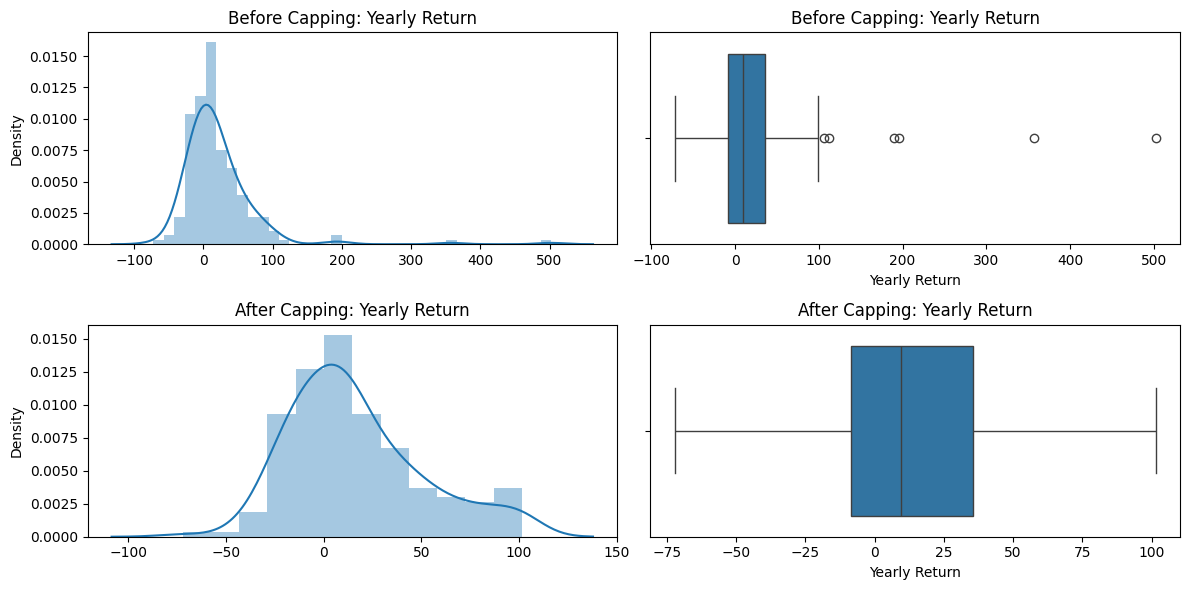

In [ ]:
def plot_outlier_handling(original_df, capped_df, col):
    plt.figure(figsize=(12, 6))

    plt.subplot(2, 2, 1)
    sns.distplot(x=original_df[col])
    plt.title(f'Before Capping: {col}')

    plt.subplot(2, 2, 2)
    sns.boxplot(x=original_df[col])
    plt.title(f'Before Capping: {col}')

    plt.subplot(2, 2, 3)
    sns.distplot(x=capped_df[col])
    plt.title(f'After Capping: {col}')

    plt.subplot(2, 2, 4)
    sns.boxplot(x=capped_df[col])
    plt.title(f'After Capping: {col}')

    plt.tight_layout()
    plt.show()

# Example usage
plot_outlier_handling(y, new_y, 'Yearly Return')

**Feature Selection**

In [ ]:
X = new_X[temp_X.columns]
y = new_y

In [ ]:
# SPLITTING INTO TRAIN AND TEST
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.35, random_state=42)

In [ ]:
# SCALING DATA TO 0-1

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

In [ ]:
# VARIANCE THRESHOLD
from sklearn.feature_selection import VarianceThreshold


var_thres = VarianceThreshold(threshold=0)
var_thres.fit(X_train)

# Finding non constant features
print(sum(var_thres.get_support()))

73


In [ ]:
constant_columns = [column for column in X_train.columns
                    if column not in X_train.columns[var_thres.get_support()]]
print(len(constant_columns))
constant_columns

9


['Renewable Energy Use',
 'Biodiversity Impact Reduction',
 'Climate Related Risks Assessment Process',
 'Green Capex',
 'Health & Safety Policy',
 'Policy Employee Health & Safety',
 'Training and Development Policy',
 'Announced Layoffs To Total Employees',
 'Different Voting Right Share']

In [ ]:
X_train = X_train.drop(constant_columns, axis=1)
X_test = X_test.drop(constant_columns, axis=1)

X_train.shape

(120, 73)

In [ ]:
X_train.columns

Index(['Energy Use Total', 'Electricity Purchased',
       'Total Water Use / Million in Revenue $', 'Water Withdrawal Total',
       'Fresh Water Withdrawal Total',
       'Total Energy Use To EVIC USD in million',
       'Water Use To EVIC USD in million', 'Targets Emissions',
       'Total CO2 Emissions / Million in Revenue $',
       'CO2 Equivalent Emissions Total',
       'CO2 Equivalent Emissions Direct Scope 1',
       'CO2 Equivalent Emissions Indirect Scope 2',
       'NOx and SOx Emissions Reduction',
       'Particulate Matter Emissions Reduction',
       'Total Waste / Million in Revenue $', 'Waste Total',
       'Non-Hazardous Waste', 'Hazardous Waste',
       'Total CO2 Equivalent Emissions To EVIC USD in million',
       'Total Waste To EVIC USD in million', 'Scope 1 Estimated Total',
       'Scope 2 Estimated Total', 'Scope 1 and 2 Estimated Total',
       'Salary Gap', 'Salaries and Wages from CSR reporting',
       'Net Employment Creation', 'Number of Employees  fro

In [ ]:
# FEATURE IMPORTANCE

# Tree based approach

from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
import matplotlib.pyplot as plt
model1 = RandomForestRegressor()
model1.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestRegressor()

In [ ]:
model2 = ExtraTreesRegressor()
model2.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


ExtraTreesRegressor()

<Axes: >

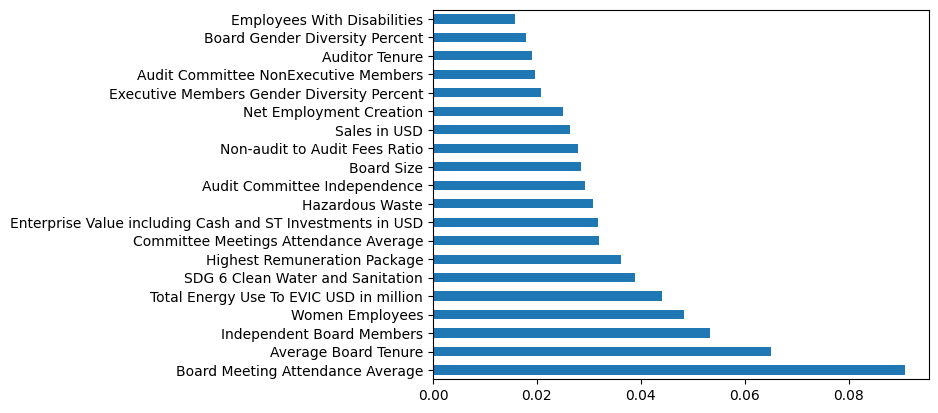

In [ ]:
ranked_features_RT = pd.Series(model1.feature_importances_, index=X_train.columns)
ranked_features_RT.nlargest(20).plot(kind = 'barh')

<Axes: >

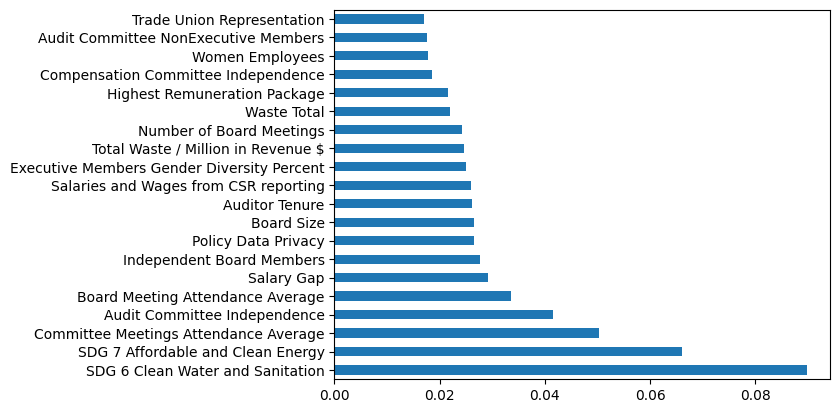

In [ ]:
ranked_features_ET = pd.Series(model2.feature_importances_, index=X_train.columns)
ranked_features_ET.nlargest(20).plot(kind = 'barh')

In [ ]:
ranked_features_RT_set = set(list(ranked_features_RT.sort_values(ascending=False).head(25).index))
ranked_features_ET_set = set(list(ranked_features_ET.sort_values(ascending=False).head(25).index))

RT_ET_Intersection = ranked_features_RT_set & ranked_features_ET_set
print(len(RT_ET_Intersection))

RT_ET_Union = ranked_features_RT_set | ranked_features_ET_set  # Will be considering this to avoid losing some of the important features
print(len(RT_ET_Union))

16
34


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


<Axes: >

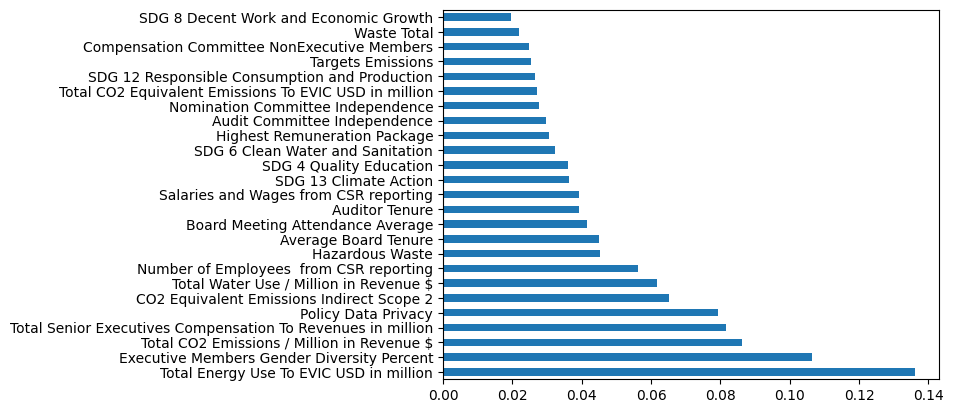

In [ ]:
# INFORMATION GAIN
from sklearn.feature_selection import mutual_info_regression

mutual_data = pd.Series(mutual_info_regression(X_train,y_train), index=X_train.columns)
mutual_data_set = set(list(mutual_data.sort_values(ascending=False).head(20).index))

mutual_data.nlargest(25).plot(kind = 'barh')

In [ ]:
# Now, we will take the union and intersection of the top 50 features obtained using the Mutual_Info method with that of the Union (features_ET and features_MT)

# Trees Intersection and Mut. Info Intersection

MI_Int_Trees_Int = RT_ET_Intersection & mutual_data_set
print(len(MI_Int_Trees_Int))

# Intersection
MI_Int_Trees_Union = RT_ET_Union & mutual_data_set
print(len(MI_Int_Trees_Union))

# Union
MI_Union_Trees_Union = RT_ET_Union | mutual_data_set
print(len(MI_Union_Trees_Union))

8
14
40


In [ ]:
final_features = list(MI_Int_Trees_Union)

In [ ]:
X = X[final_features]
X_train = X_train[final_features]
X_test = X_test[final_features]

In [ ]:
pd.DataFrame(X_train.columns)

,0
0,SDG 6 Clean Water and Sanitation
1,Total Senior Executives Compensation To Revenu...
2,Average Board Tenure
3,Total Energy Use To EVIC USD in million
4,Hazardous Waste
5,CO2 Equivalent Emissions Indirect Scope 2
6,Policy Data Privacy
7,Executive Members Gender Diversity Percent
8,Highest Remuneration Package
9,Auditor Tenure


In [ ]:
X_train.shape

(120, 14)

In [ ]:
# FITTING LINEAR REGRESSION AND CHECKING THE ASSUMPTIONS

In [ ]:
from sklearn.model_selection import KFold

In [ ]:
model = RandomForestRegressor()
model.fit(X_train, y_train)
# mse = cross_val_score(model, X_train, y_train, scoring = 'neg_mean_squared_error', cv = KFold)
# np.mean(mse)

/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestRegressor()

In [ ]:
y_pred = model.predict(X_train)

mse = mean_squared_error(y_train, y_pred)
r2 = r2_score(y_train, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

Mean Squared Error: 122.00203172505475
R-squared: 0.8749506282084926


In [ ]:
# Adjusted R - square

adj_r2 = 1 - (1 - r2) * ((X_train.shape[0] - 1) / (X_train.shape[0] - X_train.shape[1] - 1))
adj_r2

0.8249308794918896

In [ ]:
y_train = y_train.reset_index(drop=True)
result_cols = pd.concat([X_train, y_train], axis=1)

In [ ]:
result_cols

,SDG 6 Clean Water and Sanitation,Audit Committee NonExecutive Members,Waste Total,Sales in USD,CO2 Equivalent Emissions Indirect Scope 2,Salary Gap,Total Waste / Million in Revenue $,Electricity Purchased,Enterprise Value including Cash and ST Investments in USD,Total CO2 Emissions / Million in Revenue $,...,Number of Board Meetings,Total Senior Executives Compensation To Revenues in million,Independent Board Members,Average Board Tenure,Hazardous Waste,Board Size,Board Meeting Attendance Average,Employees With Disabilities,Women Employees,Yearly Return
0,-0.802394,-0.312368,-0.589107,-0.444913,-0.413411,2.010147,-0.832079,-0.530545,-0.921400,-0.726612,...,-0.382432,-0.307052,-0.917954,-0.832686,-0.677735,0.973583,-0.969952,-0.778783,-0.681392,7.968072
1,1.246271,-1.106482,-0.562506,1.237664,-0.342454,-0.557436,-0.778085,-0.639669,-0.256481,-0.683152,...,0.346010,-0.881590,-2.003559,0.637334,-0.357327,-0.303247,-0.634834,0.704403,0.815116,39.973663
2,-0.802394,0.027796,-0.573571,-0.753506,-0.597223,-0.692572,-0.512113,-0.655464,-0.934627,-0.219907,...,-0.139618,-0.696937,-0.803148,-0.513965,-0.419722,-1.580078,-0.510177,0.048633,-1.118625,21.396311
3,-0.802394,0.879100,-0.407181,0.706122,0.328917,0.118244,-0.496115,-0.043367,1.068700,-0.443498,...,0.346010,-0.721354,1.643596,-0.559496,1.890225,0.654376,-0.629978,-0.325465,-0.456014,9.721432
4,1.246271,-0.312368,-0.384682,2.164717,0.917799,-0.557436,-0.542110,-0.055744,0.338183,-0.498995,...,0.103196,-0.871134,0.459717,-0.253784,2.070730,-0.303247,0.360804,0.171865,0.030802,-21.570849
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,-0.802394,0.134432,-0.573571,-0.744944,-0.543582,-0.692572,-0.512113,-0.653996,-0.869996,-0.134359,...,0.346010,0.912605,-0.612111,-1.105875,-0.419722,0.015960,-0.268957,0.471143,-0.767035,-26.506485
116,1.246271,0.879100,-0.567012,2.380496,0.876109,-0.557436,-0.804082,-0.639669,-0.306117,-0.611807,...,2.774150,-0.914516,0.108870,-1.314019,-0.361296,0.335168,1.021326,0.704403,0.035309,42.939662
117,1.246271,0.879100,-0.426440,-0.144442,-0.683509,-0.557436,0.173815,-0.776268,0.924597,1.962380,...,0.588824,-0.676748,-0.229118,-0.312325,1.894972,0.335168,0.043495,0.893653,-0.428969,4.779061
118,-0.802394,0.217239,-0.588137,-0.720334,-0.509456,-0.287164,-0.794083,-0.607653,-0.955491,-0.736504,...,-1.596502,-0.276962,1.684008,-0.136703,-0.670757,-1.260870,-1.350399,-0.145018,-0.654347,-4.477309


In [ ]:
# 1) LINEARITY ASSUMPTION

In [ ]:
results_df = pd.DataFrame({'Actual': np.array(y_train).flatten(), 'Predicted': np.array(y_pred).flatten()})

In [ ]:
results_df['Residuals'] = results_df['Actual'] - results_df['Predicted']
print(results_df.head())

np.mean(results_df['Residuals'])

      Actual  Predicted  Residuals
0   7.968072  13.482107  -5.514036
1  39.973663  42.481309  -2.507646
2  21.396311  14.252134   7.144178
3   9.721432   9.426130   0.295303
4 -21.570849  -8.187330 -13.383519


np.float64(-0.6563678516691044)

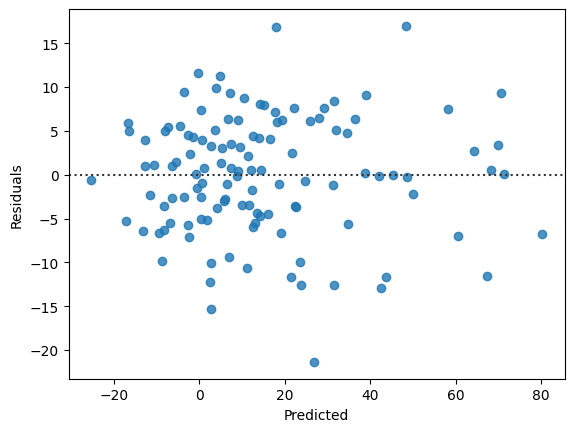

In [ ]:
sns.residplot(x='Predicted', y='Residuals', data=results_df)
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.show()

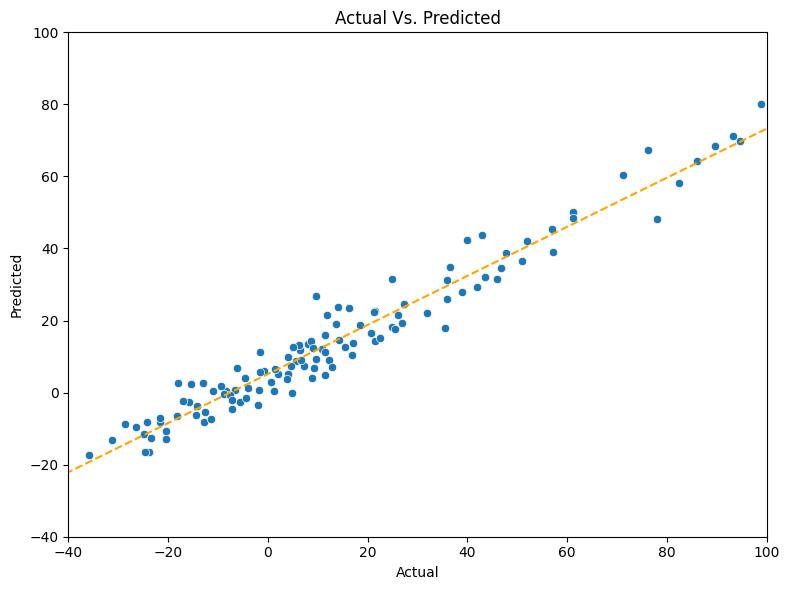

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))



sns.scatterplot(x='Actual', y='Predicted', data=results_df)


plt.plot(np.unique(results_df['Actual']), np.poly1d(np.polyfit(results_df['Actual'], results_df['Predicted'], 1))(np.unique(results_df['Actual'])), color = 'orange', linestyle = '--')

ax.axis([-40, 100, -40, 100])
plt.title('Actual Vs. Predicted')
plt.xlabel('Actual')
plt.ylabel('Predicted')





plt.tight_layout()
plt.show()



In [ ]:
# From the plot, we can see that linearity is present but the best fit line is almost horizontal, suggesting almost no impact of independent variables on the dependent variable.

In [ ]:
from statsmodels.stats.diagnostic import normal_ad

In [ ]:
# NORMALITY ASSUMPTION



# Performing Anderson-Darling test for Normal Distribution

p_value = normal_ad(results_df['Residuals'])[1]
print(f"P-value: {p_value}")

alpha = 0.05
if p_value < alpha:
    print("The residuals are not normally distributed.")
else:
    print("The residuals are normally distributed.")

P-value: 0.023003147578521274
The residuals are not normally distributed.


<ipython-input-154-973a25439a16>:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(results_df['Residuals'], kde = True)


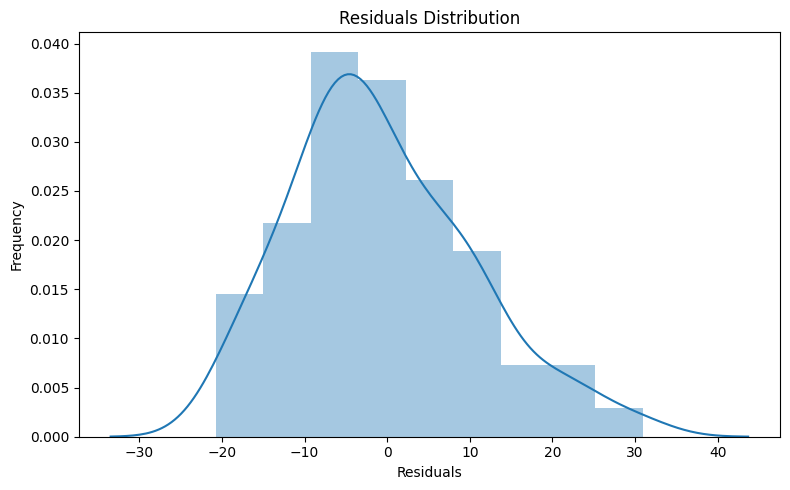

In [ ]:
plt.figure(figsize=(8, 5))

sns.distplot(results_df['Residuals'], kde = True)
plt.title('Residuals Distribution')
plt.xlabel('Residuals')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [ ]:
# Checking for the Skewness of the Residuals

print(f"Skewness of Residuals: {results_df['Residuals'].skew()}")
if results_df['Residuals'].skew() > 1:
  print("The residuals are positively skewed.")
elif results_df['Residuals'].skew() < -1:
  print("The residuals are negatively skewed.")
else:
  print("Residuals are not skewed.")

Skewness of Residuals: 0.5883349543278817
Residuals are not skewed.


In [ ]:
# ASSUMPTION 3: CHECKING MULTICOLLINEARITY

# Using Pearson Correlation

def correlation(dataset, threshold):
  col_corr = set()
  corr_matrix = dataset.corr()
  for i in range(len(corr_matrix.columns)):
    for j in range(i):
      if abs(corr_matrix.iloc[i, j]) > threshold:
        colname = corr_matrix.columns[i]
        col_corr.add(colname)
  return col_corr

In [ ]:
corr_features = correlation(X_train, 0.80)
len(set(corr_features))

0

In [ ]:
corr_features

set()

In [ ]:
X_train.drop(corr_features, inplace = True, axis = 1)
X_test.drop(corr_features, inplace = True, axis = 1)

In [ ]:
X_train.shape

(120, 14)

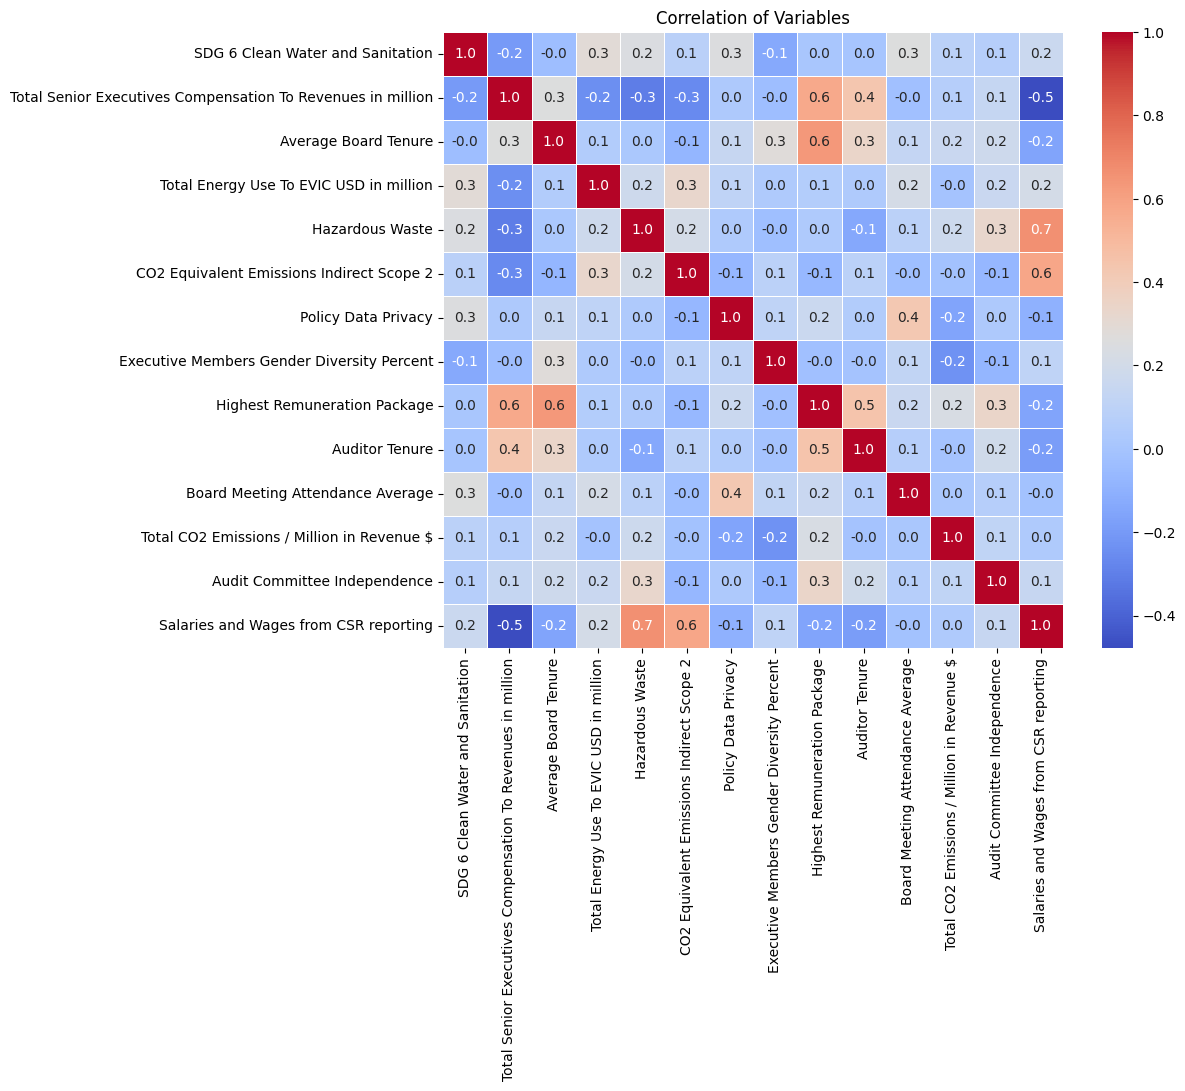

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

plt.figure(figsize=(10,8))

feature_names =  X_train.columns
sns.heatmap(pd.DataFrame(X_train, columns=feature_names).corr(), annot=True, fmt = '.1f', annot_kws=dict(size = 10), linewidth=.5, cmap='coolwarm')
plt.title('Correlation of Variables')
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()


In [ ]:
def calculate_vif(df):
    vif_df = pd.DataFrame()
    vif_df['Feature'] = df.columns
    vif_df['VIF'] = [variance_inflation_factor(df.values, i) for i in range(df.shape[1])]
    return vif_df

def remove_high_vif_features(X, threshold=5):
    while True:
        vif_df = calculate_vif(X)
        max_vif = vif_df['VIF'].max()
        if max_vif > threshold:
            drop_feature = vif_df.sort_values('VIF', ascending=False)['Feature'].iloc[0]
            print(f"Dropping '{drop_feature}' with VIF = {max_vif:.2f}")
            X = X.drop(columns=[drop_feature])
        else:
            break
    return X

In [ ]:
X_train = remove_high_vif_features(X_train)

X_test = X_test[X_train.columns]

In [ ]:
# ASSUMPTION 4: NO AUTOCORRELATION OF ERROR TERMS

from statsmodels.stats.stattools import durbin_watson

print('Value of 1.5 < d < 2.5 show that there is no autocorrelation in the data.')

Durbinwatson = durbin_watson(results_df['Residuals'])
print(f'Durbin Watson Statistic: {Durbinwatson}')
if Durbinwatson < 1.5:
  print('Assumption not satisfied: Signs of Positive Autocorrelation')
elif Durbinwatson > 2.5:
  print('Assumption not satisfied: Signs of Negative Autocorrelation')
else:
  print('Little to no autocorrelation')
  print('Assumption satisfied')

Value of 1.5 < d < 2.5 show that there is no autocorrelation in the data.
Durbin Watson Statistic: 1.7612287339975787
Little to no autocorrelation
Assumption satisfied


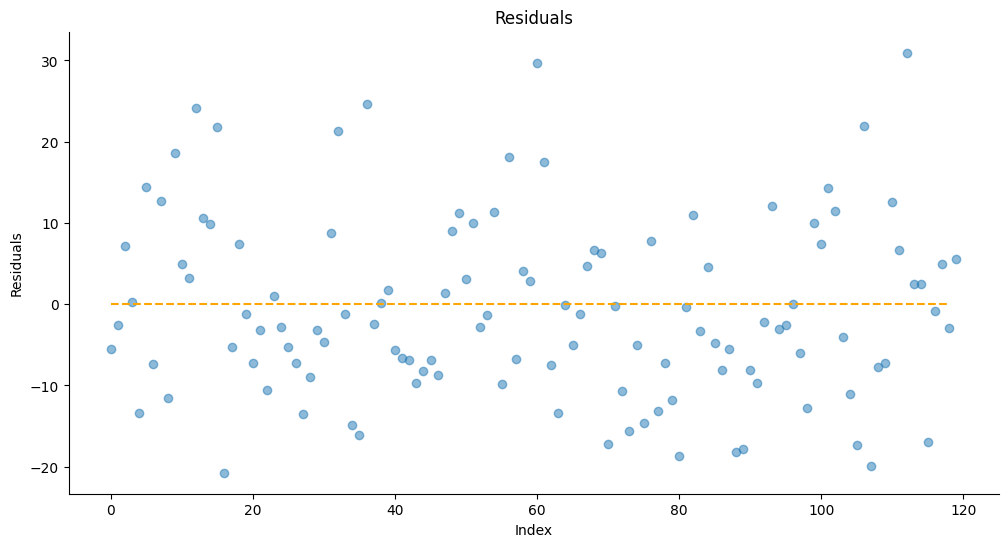

In [ ]:
# ASSUMPTION 5: HOMOSCEDASTICITY

plt.subplots(figsize = (12,6))
ax = plt.subplot(111)
plt.scatter(x = results_df.index, y = results_df.Residuals, alpha = 0.5)
plt.plot(np.repeat(0, results_df.index.max()), color = 'orange', linestyle = '--')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.title('Residuals')
plt.xlabel('Index')
plt.ylabel('Residuals')
plt.show()

In [ ]:
model.fit(X_train, y_train)
y_pred = model.predict(X_train)

mse = mean_squared_error(y_train, y_pred)
r2 = r2_score(y_train, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Mean Squared Error: 121.56565176436983
R-squared: 0.8753979079723987


In [ ]:
X_train.columns

Index(['Highest Remuneration Package', 'SDG 6 Clean Water and Sanitation',
       'Hazardous Waste', 'Executive Members Gender Diversity Percent',
       'Salary Gap', 'Audit Committee Independence',
       'Salaries and Wages from CSR reporting',
       'Total Senior Executives Compensation To Revenues in million',
       'Average Board Tenure', 'Board Meeting Attendance Average',
       'Total Energy Use To EVIC USD in million', 'Auditor Tenure',
       'Policy Data Privacy'],
      dtype='object')

In [ ]:
# SELECT K  BEST

In [ ]:
pd.DataFrame(X_train.columns)

In [ ]:
# CORRELATION MATRIX


In [ ]:
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

In [ ]:
from sklearn.linear_model import LassoCV

model = LassoCV(cv=5).fit(X_train, y_train)
print("Selected Features with Lasso:")
print(pd.Series(model.coef_, index=X_train.columns)[model.coef_ != 0])